In [2]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

### 0. First tidy up NaNs, because couldn't split the data with NaNs
strategy: checking all the data inputs and ratio of NaN values in the dataset

In [5]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


In [6]:
df[df.isin(['NO RESPONSE']).any(axis=1)]

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
16,2.0,4.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NaN
31,3.0,17.0,2.0,2.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,NO,NO
39,4.0,5.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,DUG WELL: PROTECTED WELL,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
67,6.0,14.0,2.0,2.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,25.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,1101.0,4.0,1.0,1.0,14.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO RESPONSE,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,90.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO
13100,1107.0,4.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,YES,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13124,1109.0,1.0,1.0,1.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,NO,TUBE WELL / BOREHOLE,ELSEWHERE,150.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13127,1109.0,7.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,NO,NO,DUG WELL: UNPROTECTED WELL,NO RESPONSE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES


_Significantly more NaNs than expected!_\
_Not only do we have a couple of columns with a high number of NaNs (HW5,FCD5, CL3(!!)), but also 12458 / 13162 rows have at least 1 missing vaulue -> can't just delete rows with missing values as we'd have a fraction of the dataset left._

In [7]:
df = df.fillna('NO RESPONSE')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13162 non-null  object 
 5   CB4         13162 non-null  object 
 6   CB5A        13162 non-null  object 
 7   CB5B        13162 non-null  object 
 8   CB7         13162 non-null  object 
 9   CB11        13162 non-null  object 
 10  CL3         13162 non-null  object 
 11  CL13        13162 non-null  object 
 12  FCD2A       13162 non-null  object 
 13  FCD2B       13162 non-null  object 
 14  FCD2C       13162 non-null  object 
 15  FCD2D       13162 non-null  object 
 16  FCD2E       13162 non-null  object 
 17  FCD2F       13162 non-null  object 
 18  FCD2G       13162 non-null  object 
 19  FCD2H       13162 non-nul

Filled with "NO RESPONSE" globally to split into test/training. More data investigation after the split

In [9]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

See if any of the missing information is correlated

<Axes: >

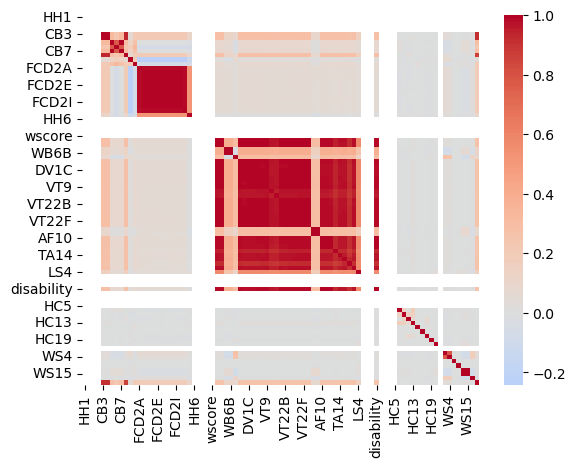

In [10]:
no_response_matrix = (df_train == 'NO RESPONSE').astype(int)
no_response_corr = no_response_matrix.corr()
sns.heatmap(no_response_corr, cmap='coolwarm', center=0, annot=False)

101 missing FCF26 responses - dropping

In [11]:
df_train = df_train[df_train['FCF26'] != 'NO RESPONSE']
df_test = df_test[df_test['FCF26'] != 'NO RESPONSE']

#### 0.1 checking if there is any reason for the missing data (Child Labour subset)

In [12]:
cols = ['CL2','CL3', 'CL12', 'CL13', 'FCF26']
df_train[df_train['CL3'].isin(['NO RESPONSE'])][cols]

,CL2,CL3,CL12,CL13,FCF26
773,False,NO RESPONSE,True,1.0,A FEW TIMES A YEAR
2464,False,NO RESPONSE,True,4.0,MONTHLY
5113,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
10868,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
7909,False,NO RESPONSE,True,0.0,NEVER
...,...,...,...,...,...
6910,False,NO RESPONSE,False,NO RESPONSE,NEVER
295,False,NO RESPONSE,True,3.0,MONTHLY
2558,False,NO RESPONSE,True,3.0,A FEW TIMES A YEAR
6331,False,NO RESPONSE,True,30.0,NEVER


In [13]:
## check how False / True translates to CL2
df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True)

CL2
False    1.0
Name: proportion, dtype: float64

_Conclusion: whereever CL2 is False (Child Labour = False), there's a missing CL3 value. This means, all CL3 NaNs can be made 0, as the child is NOT working = 0 working hours._

In [14]:
df_train.CL3.unique()

array(['NO RESPONSE', 3.0, 1.0, 20.0, 0.0, 28.0, 6.0, 2.0, 5.0, 4.0, 12.0,
       10.0, 14.0, 13.0, 7.0, 36.0, 9.0, 11.0, 8.0, 40.0, 23.0, 30.0,
       15.0, 21.0, 42.0, 18.0, 63.0, 77.0, 60.0, 27.0, 26.0, 24.0, 56.0,
       16.0, 25.0, 35.0, 43.0, 22.0, 32.0, 49.0, 70.0, 66.0, 45.0, 55.0,
       72.0, 17.0], dtype=object)

In [15]:
df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_92996/2669409082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_92996/2669409082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)


In [16]:
df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True)

CL12
False    0.998724
True     0.001276
Name: proportion, dtype: float64

In [17]:
df_train.CL13.unique()

array(['1.0', '6.0', '4.0', '16.0', '0.0', '25.0', '5.0', 'NO RESPONSE',
       '20.0', '14.0', '2.0', '8.0', '3.0', '10.0', '30.0', '7.0', '11.0',
       '15.0', '17.0', '48.0', '9.0', '44.0', '13.0', '23.0', '12.0',
       '39.0', '22.0', '40.0', '35.0', '42.0', '18.0', '21.0', '28.0',
       '19.0', '24.0', '43.0', '60.0', '50.0', '45.0', '51.0', '26.0',
       '34.0', '29.0', '33.0', '32.0', '66.0', '54.0', '31.0', '56.0',
       '72.0', '55.0'], dtype=object)

_99.8% of data for CL13 and CL12 follow the same rule -> make CL13 0.0_

In [18]:
df_train['CL13'] = df_train['CL13'].replace('NO RESPONSE', 0.0)
df_test['CL13'] = df_test['CL13'].replace('NO RESPONSE', 0.0)

In [19]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 46369
Rows with any "NO RESPONSE": 8776


In [20]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD5       3933
HW5        2777
MA3        2376
MA2        2352
WB14       2303
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
FCF26         0
Length: 87, dtype: int64

FCD5. _Do you believe that in order to bring up, raise, or educate a child properly, the child needs to be physically punished?_\
checing correlation with other FCD columns

FCD2A-K are different types of physical punishment methods

In [21]:
fcd_cols = ['FCD5','FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']
df_train[df_train['FCD5'] == 'NO RESPONSE'][fcd_cols + ['FCF26']]

,FCD5,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,FCD2G,FCD2H,FCD2I,FCD2J,FCD2K,FCF26
773,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,A FEW TIMES A YEAR
2464,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,YES,NO,NO,NO,MONTHLY
11506,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
7909,NO RESPONSE,YES,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,NEVER
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
2558,NO RESPONSE,YES,YES,NO,YES,YES,YES,YES,YES,NO,NO,NO,A FEW TIMES A YEAR
5304,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
6331,NO RESPONSE,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,NEVER


In [22]:
df_train[df_train['FCD2K'] == 'NO RESPONSE'][fcd_cols].value_counts(normalize=True)

FCD5         FCD2A        FCD2B        FCD2C        FCD2D        FCD2E        FCD2F        FCD2G        FCD2H        FCD2I        FCD2J        FCD2K      
NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE    0.984962
NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000684
NO RESPONSE  NO           YES          NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000684
YES          NO           YES          NO           YES          YES          NO           NO           YES          YES          NO           NO RESPONSE    0.000684
NO RESPONSE  YES          YES          YES          YES          NO           YES          NO           YES          NO           NO           NO RESPONSE    0.000684
          

<Axes: >

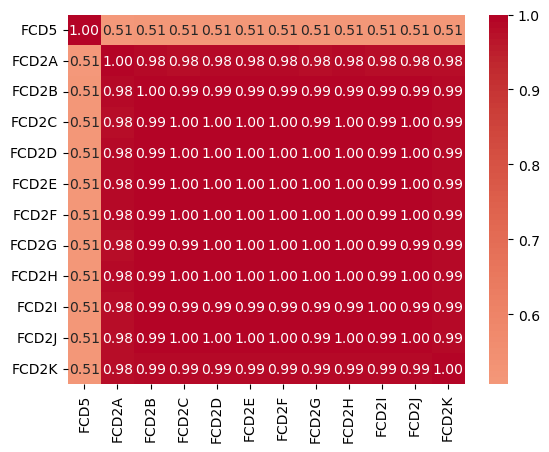

In [23]:
fcd_no_resp = (df_train[fcd_cols] == 'NO RESPONSE').astype(int)
sns.heatmap(fcd_no_resp.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')

_Conclusion: If there is missing data for one Physical punishment type (FCD2) column, it is missing in almost all the other FCD2X ones -> it looks like an intentional skip, but we can't quite tell if it's missed because a person doesn't want to disclose what kind of punishment they use OR they don't agree with punishment. First step: if FCD2 columns are ALL "NO", make FCD5 "NO RESPONSE" a "NO" too. If there's any "YES" make it a "YES"._

In [24]:
fcd2_cols = ['FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

for df in [df_train, df_test]:
    mask = df['FCD5'].isin(['NO RESPONSE', 'DK / NO OPINION'])
    
    any_yes = df.loc[mask, fcd2_cols].isin(['YES']).any(axis=1)
    df.loc[mask & any_yes, 'FCD5'] = 'YES'
    
    all_no = (df.loc[mask, fcd2_cols] == 'NO').all(axis=1)
    df.loc[mask & all_no, 'FCD5'] = 'NO'

In [25]:
df_train['FCD5'].value_counts()

FCD5
NO             5440
YES            3544
NO RESPONSE    1444
Name: count, dtype: int64

In [26]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
MA3        2376
MA2        2352
WB14       2303
FCD2A      1479
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
FCF26         0
Length: 87, dtype: int64

HW5. _Do you have any soap or detergent or ash/mud/sand in your house for washing hands?_

MA2. How old is your (husband/partner)?
Probe: How old was your (husband/partner) on his last birthday?

MA3. Besides yourself, does your (husband/partner) have any other wives or partners or does he live with other women as if married?

In [27]:
top_NaNs_cols = ['HW5','MA3', 'MA2']
df_train[df_train['MA2'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,MA3,MA2,FCF26
11506,NO,NO RESPONSE,NO RESPONSE,WEEKLY
7909,YES,NO RESPONSE,NO RESPONSE,NEVER
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
12931,YES,NO RESPONSE,NO RESPONSE,WEEKLY
10140,NO,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...
8465,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
10276,YES,NO RESPONSE,NO RESPONSE,MONTHLY
8734,YES,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
8307,NO,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR


In [28]:
df_train[df_train['MA3'] == 'NO RESPONSE']['MSTATUS'].value_counts(normalize=True)

MSTATUS
Formerly married/in union     0.843013
Never married/in union        0.088384
Currently married/in union    0.068603
Name: proportion, dtype: float64

In [29]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

married_mask_train = df_train['MSTATUS'] == 'Currently married/in union'
married_mask_test = df_test['MSTATUS'] == 'Currently married/in union'

df_train.loc[married_mask_train, ['MA2', 'MA3']] = imputer.fit_transform(
    df_train.loc[married_mask_train, ['MA2', 'MA3']]
)
df_test.loc[married_mask_test, ['MA2', 'MA3']] = imputer.transform(
    df_test.loc[married_mask_test, ['MA2', 'MA3']]
)

In [30]:
df_train['MA2'].value_counts(normalize=True)

MA2
NO RESPONSE    0.212217
40.0           0.053414
35.0           0.039317
45.0           0.034522
37.0           0.032892
                 ...   
85.0           0.000096
13.0           0.000096
12.0           0.000096
11.0           0.000096
16.0           0.000096
Name: proportion, Length: 70, dtype: float64

In [31]:
df_train.loc[df_train['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_train.loc[df_train['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'
df_test.loc[df_test['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_test.loc[df_test['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'

MA2 and MA3 perfect correlation — likely no husband -> leaving as "NO RESPONSE"

WB5. _Have you ever attended school or any early childhood education programme?_

WB6. _What is the highest level and grade or year of school you have attended?_

In [32]:
top_NaNs_cols = ['HW5','WB14', 'WB5', 'WB6B', 'WB6A']
df_train[df_train['WB14'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,WB14,WB5,WB6B,WB6A,FCF26
2464,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,HIGHER,MONTHLY
11506,NO,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
9934,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
1377,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 3,UPPER SECONDARY,NEVER
12665,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,DAILY
...,...,...,...,...,...,...
12800,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
5578,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
9431,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
2777,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,NEVER


In [33]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['MA2']] = imputer.fit_transform(df_train[['MA2']])
df_test[['MA2']] = imputer.transform(df_test[['MA2']])

In [34]:
print(df_train['WB5'].value_counts(normalize=True))
print(df_train['WB6A'].value_counts(normalize=True))
print(df_train['WB6B'].value_counts(normalize=True))
print(df_train['WB14'].value_counts(normalize=True))

WB5
YES            0.859417
NO             0.118815
NO RESPONSE    0.021768
Name: proportion, dtype: float64
WB6A
PRIMARY                0.659474
NO RESPONSE            0.140583
LOWER SECONDARY        0.096279
UPPER SECONDARY        0.083909
HIGHER                 0.017837
VOCATIONAL TRAINING    0.001534
ECE                    0.000384
Name: proportion, dtype: float64
WB6B
CLASS/GRADE 8         0.143748
CLASS/YEAR/GRADE 4    0.141063
NO RESPONSE           0.140967
CLASS/YEAR/GRADE 2    0.124664
CLASS/GRADE 7         0.107211
CLASS/YEAR/GRADE 3    0.098964
CLASS/YEAR/GRADE 5    0.096375
CLASS/GRADE 6         0.084580
CLASS/YEAR/GRADE 1    0.062332
DK                    0.000096
Name: proportion, dtype: float64
WB14
ABLE TO READ WHOLE SENTENCE                   0.356348
CANNOT READ AT ALL                            0.338991
NO RESPONSE                                   0.220848
ABLE TO READ ONLY PARTS OF SENTENCE           0.081511
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE    0.002301
N

In [35]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['WB6A', 'WB6B', 'WB14']] = imputer.fit_transform(df_train[['WB6A','WB6B', 'WB14']])
df_test[['WB6A','WB6B', 'WB14']] = imputer.transform(df_test[['WB6A','WB6B', 'WB14']])
df_train.loc[df_train['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'
df_test.loc[df_test['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'

If WB5 is "NO" or NaN, WB6A and WB6B have missing values. Most likely the woman just didn't attend school. WB14 for most of the WB5/6A/6B entries is "CANNOT READ AT ALL" with a few exceptions -> changing WB5 to "NO" and WB6A/B to "NO EDUCATION";

In [36]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

WS1. _What is the main source of drinking water used by members of your household?_

WS3. _Where is that water source located?_

WS4. _How long does it take for members of your household to go there, get water, and come back?_

WS7. _In the last month, has there been any time when your household did not have sufficient quantities of drinking water?_

WS11. _What kind of toilet facility do members of your household usually use?_

WS14. _Where is this toilet facility located?_

WS15. _Do you share this facility with others who are not members of your household?_

In [37]:
household_cols = ['HW5', 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15']
df_train[df_train['WS4'] == 'NO RESPONSE'][household_cols + ['FCF26']]

,HW5,WS1,WS3,WS4,WS7,WS11,WS14,WS15,FCF26
2464,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,MONTHLY
9934,NO RESPONSE,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM,IN OWN DWELLING,NO,NEVER
11999,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,IN OWN YARD / PLOT,NO RESPONSE,"NO, ALWAYS SUFFICIENT",NO FACILITY / BUSH / FIELD,NO RESPONSE,NO RESPONSE,NEVER
527,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,A FEW TIMES A YEAR
1206,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
...,...,...,...,...,...,...,...,...,...
2213,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",OTHER,ELSEWHERE,YES,A FEW TIMES A YEAR
12800,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
9431,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: VENTILATED IMPROVED PIT LATRINE,IN OWN YARD / PLOT,NO,A FEW TIMES A YEAR
6910,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER


In [38]:
df_train.WS4.unique()

array(['30.0', 'NO RESPONSE', '5.0', '15.0', 'DK', '10.0', '60.0', '25.0',
       '8.0', '7.0', '75.0', '45.0', '20.0', '180.0', '120.0', '90.0',
       '2.0', '40.0', '12.0', '1.0', '17.0', '4.0', '3.0', '50.0', '6.0',
       '24.0', '112.0', '9.0', '55.0', '155.0', '35.0', '100.0', '130.0',
       'MEMBERS DO NOT COLLECT', '42.0', '70.0', '14.0', '240.0', '65.0',
       '22.0', '300.0', '18.0', '13.0', '610.0', '153.0', '41.0', '54.0',
       '80.0', '16.0', '36.0', '34.0', '23.0', '52.0', '360.0', '11.0',
       '21.0', '110.0', '214.0', '540.0', '160.0', '304.0', '200.0',
       '900.0', '26.0', '135.0', '28.0', '98.0', '19.0', '31.0', '46.0',
       '390.0', '95.0', '220.0', '66.0', '33.0', '38.0', '49.0', '32.0',
       '27.0', '48.0'], dtype=object)

In [39]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
NO RESPONSE           0.672401
IN OWN YARD / PLOT    0.309677
IN OWN DWELLING       0.017921
Name: proportion, dtype: float64

In [40]:
df_train['WS4'].value_counts(normalize=True)

WS4
10.0           0.158899
NO RESPONSE    0.133774
30.0           0.131569
20.0           0.107883
5.0            0.091580
                 ...   
41.0           0.000096
153.0          0.000096
610.0          0.000096
112.0          0.000096
48.0           0.000096
Name: proportion, Length: 80, dtype: float64

In [41]:
df_train[df_train['WS3'] == 'NO RESPONSE']['WS1'].value_counts(normalize=True)

WS1
PIPED WATER: PIPED TO YARD / PLOT                                            0.776749
PIPED WATER: PIPED INTO DWELLING                                             0.186214
TUBE WELL / BOREHOLE                                                         0.023663
DUG WELL: UNPROTECTED WELL                                                   0.003086
PACKAGED WATER: BOTTLED WATER                                                0.002058
DUG WELL: PROTECTED WELL                                                     0.002058
CART WITH SMALL TANK                                                         0.002058
TANKER-TRUCK                                                                 0.001029
PIPED WATER: PUBLIC TAP / STANDPIPE                                          0.001029
PIPED WATER: PIPED TO NEIGHBOUR                                              0.001029
SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)    0.001029
Name: proportion, dtype: float64

most of missing data in WS3 has answers in WS1 -> Piped to yard/dwelling. 

Changing all NAs to "IN OWN YARD / PLOT". 

WS4 NaN for when WS3 "IN OWN YARD / PLOT", so changing to "MEMBERS DO NOT COLLECT"

In [42]:
df_train.loc[df_train['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'
df_test.loc[df_test['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'

In [43]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
IN OWN YARD / PLOT    0.982079
IN OWN DWELLING       0.017921
Name: proportion, dtype: float64

In [44]:
df_train.loc[df_train['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_test.loc[df_test['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'

In [45]:
df_train[df_train['WS14'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
NO FACILITY / BUSH / FIELD          0.997449
HANGING TOILET / HANGING LATRINE    0.002551
Name: proportion, dtype: float64

99.7% have no toilet where "no response". changing no response to "NO TOILET"

In [46]:
df_train.loc[df_train['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'
df_test.loc[df_test['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'

In [47]:
df_train.WS4.unique()
df_train.WS4.value_counts()

WS4
10.0                      1657
MEMBERS DO NOT COLLECT    1419
30.0                      1372
20.0                      1125
5.0                        955
                          ... 
41.0                         1
153.0                        1
610.0                        1
112.0                        1
48.0                         1
Name: count, Length: 79, dtype: int64

In [48]:
df_train.loc[df_train['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0
df_test.loc[df_test['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0

In [49]:
df_train[df_train['WS4'] == 'DK']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE    1.0
Name: proportion, dtype: float64

Set to the most frequent value

In [50]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['WS4']] = imputer.fit_transform(df_train[['WS4']])
df_test[['WS4']] = imputer.transform(df_test[['WS4']])

In [51]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

In [52]:
df_train[df_train['WS15'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)


WS14
NO TOILET             0.987374
IN OWN YARD / PLOT    0.011364
ELSEWHERE             0.001263
Name: proportion, dtype: float64

Setting all "NO RESPONSE" to "YES" -> if they don't have a toilet, they share it with others, whether it's a bush or whatever else.

In [53]:
df_train.loc[df_train.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'
df_test.loc[df_test.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'

In [54]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 29743
Rows with any "NO RESPONSE": 5265


In [55]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)

WS14
IN OWN YARD / PLOT    0.781419
IN OWN DWELLING       0.094707
ELSEWHERE             0.083543
NO TOILET             0.040331
Name: proportion, dtype: float64

In [56]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
PIT LATRINE: PIT LATRINE WITH SLAB                  0.740367
PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT    0.097587
PIT LATRINE: VENTILATED IMPROVED PIT LATRINE        0.054015
FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK            0.052935
NO FACILITY / BUSH / FIELD                          0.040331
OTHER                                               0.006122
FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM     0.003961
FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE            0.001801
HANGING TOILET / HANGING LATRINE                    0.001801
FLUSH / POUR FLUSH: FLUSH TO DK WHERE               0.000360
FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN             0.000360
COMPOSTING TOILET                                   0.000360
Name: proportion, dtype: float64

In [57]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE             0.766295
IN OWN YARD / PLOT    0.230104
IN OWN DWELLING       0.003601
Name: proportion, dtype: float64

In [58]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS4'].value_counts(normalize=True)

WS4
0.0      0.232265
10.0     0.151602
30.0     0.117033
20.0     0.098668
5.0      0.085704
15.0     0.081023
60.0     0.064818
45.0     0.016925
25.0     0.016565
40.0     0.015484
2.0      0.012604
120.0    0.011163
3.0      0.011163
8.0      0.009723
6.0      0.009723
50.0     0.009363
4.0      0.007562
12.0     0.006842
7.0      0.006482
35.0     0.005762
1.0      0.005041
90.0     0.003241
13.0     0.001801
80.0     0.001801
100.0    0.001440
14.0     0.001440
70.0     0.001080
55.0     0.001080
19.0     0.000720
21.0     0.000720
9.0      0.000720
65.0     0.000720
200.0    0.000720
160.0    0.000720
180.0    0.000720
18.0     0.000720
300.0    0.000720
240.0    0.000720
540.0    0.000360
22.0     0.000360
32.0     0.000360
49.0     0.000360
98.0     0.000360
135.0    0.000360
16.0     0.000360
24.0     0.000360
214.0    0.000360
11.0     0.000360
36.0     0.000360
610.0    0.000360
153.0    0.000360
900.0    0.000360
17.0     0.000360
Name: proportion, dtype: float64

Most of the HW5 missing answers have latrines in their own yards, but water sources elsewhere, so most likely don't wash their hands. Changing 'NO RESPONSE' to 'NO'

In [59]:
df_train.loc[df_train.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'
df_test.loc[df_test.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'

In [60]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
FCD2G      1448
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

CB3. How old is (name)?  

CB4. Has (name) ever attended school or any early childhood education programme?

CB5. What is the highest level and grade or year of school (name) has ever attended?

CB7. At any time during the current school year did (name) attend school or any early childhood education programme?

CB11. Is (name) covered by any health insurance?

In [61]:
df_train.CB5A.unique()

array(['PRIMARY', 'NO RESPONSE', 'ECE', 'UPPER SECONDARY',
       'LOWER SECONDARY', 'HIGHER'], dtype=object)

In [62]:
df_train[df_train['CB5A'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.609001
6.0     0.178622
7.0     0.067511
8.0     0.029536
10.0    0.022504
9.0     0.019691
15.0    0.016878
14.0    0.011252
12.0    0.011252
17.0    0.009845
11.0    0.008439
13.0    0.008439
16.0    0.007032
Name: proportion, dtype: float64

likely just not in school age yet!

In [63]:
df_train[df_train['CB5B'] == 'NO RESPONSE']['CB4'].value_counts(normalize=True)

CB4
NO             0.587065
YES            0.411277
NO RESPONSE    0.001658
Name: proportion, dtype: float64

In [64]:
df_train[df_train['CB7'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.609859
6.0     0.178873
7.0     0.067606
8.0     0.029577
10.0    0.022535
9.0     0.019718
15.0    0.016901
14.0    0.011268
12.0    0.011268
17.0    0.009859
11.0    0.008451
16.0    0.007042
13.0    0.007042
Name: proportion, dtype: float64

changing NO RESPONSE to NOT SCHOOL AGE in both CB5A and CB5B

In [65]:
df_train.loc[df_train.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

df_test.loc[df_test.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

In [66]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
WB14        0
HH2         0
MA2         0
MA3         0
FCF26       0
Length: 87, dtype: int64

LS1. I would like to ask you some simple questions on happiness and satisfaction. \
First, taking all things together, would you say you are very happy, somewhat happy, neither happy nor unhappy, somewhat unhappy or very unhappy?

I am now going to show you pictures to help you with your response.

LS2. Show the picture of the ladder.\
Now, look at this ladder with steps numbered from 0 at the bottom to 10 at the top.
Suppose we say that the top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you.
On which step of the ladder do you feel you stand at this time?


LS3. Compared to this time last year, would you say that your life has improved, stayed more or less the same, or worsened, overall?

LS4. And in one year from now, do you expect that your life will be better, will be more or less the same, or will be worse, overall?

In [67]:
df_train[df_train['LS4'] == 'NO RESPONSE'][['LS3','LS1', 'LS2']].value_counts(normalize=True)

LS3                    LS1                        LS2        
NO RESPONSE            NO RESPONSE                NO RESPONSE    0.308424
MORE OR LESS THE SAME  VERY HAPPY                 10             0.038043
IMPROVED               VERY HAPPY                 10             0.035326
MORE OR LESS THE SAME  NEITHER HAPPY NOR UNHAPPY  5              0.028533
                       VERY HAPPY                 0              0.027174
                                                                   ...   
NO RESPONSE            VERY UNHAPPY               NO RESPONSE    0.001359
WORSENED               NEITHER HAPPY NOR UNHAPPY  4              0.001359
                                                  6              0.001359
                                                  8              0.001359
                       VERY UNHAPPY               NO RESPONSE    0.001359
Name: proportion, Length: 132, dtype: float64

In [68]:
df_train.LS4.value_counts(normalize=True)

LS4
BETTER                   0.621692
MORE OR LESS THE SAME    0.241753
NO RESPONSE              0.070579
WORSE                    0.065976
Name: proportion, dtype: float64

majority of LS4 'NO RESPONSE' skipped the whole LS section. Filling in based on the most frequent answers

In [69]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['LS1','LS2', 'LS3','LS4']] = imputer.fit_transform(df_train[['LS1','LS2', 'LS3','LS4']])
df_test[['LS1','LS2', 'LS3','LS4']] = imputer.transform(df_test[['LS1','LS2', 'LS3','LS4']])

In [70]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
MA2         0
MA3         0
LS1         0
LS2         0
FCF26       0
Length: 87, dtype: int64

Using the "most frequent" strategy for all the remaining "no response", as there aren't that many counts per columns anymore

In [71]:
no_response = (df_train == 'NO RESPONSE').sum() / len(df_train)
cols_to_impute = (no_response[no_response < 0.05]).index.tolist()

imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[cols_to_impute] = imputer.fit_transform(df_train[cols_to_impute])
df_test[cols_to_impute] = imputer.transform(df_test[cols_to_impute])

In [72]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
DV1C        0
DV1B        0
DV1A        0
WB14        0
FCF26       0
Length: 87, dtype: int64

VT20. How safe do you feel walking alone in your neighbourhood after dark?

VT21. How safe do you feel when you are at home alone after dark?

VT22. In the past 12 months, have you personally felt discriminated against or harassed on the basis of the following grounds?

In [73]:
df_train[df_train['VT22A'] == 'NO RESPONSE']['VT21'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

---

---

### 1. Now that all NaNs/NO RESPONSE were handled, categorise the data

In [74]:
df_train.FCF26.unique()

array(['A FEW TIMES A YEAR', 'NEVER', 'MONTHLY', 'WEEKLY', 'DAILY'],
      dtype=object)

In [75]:
df_train.FCF26 = np.where(df_train['FCF26'] == 'NEVER', 0, 1)
df_test.FCF26 = np.where(df_test['FCF26'] == 'NEVER', 0, 1)
df_train.FCF26.unique()

array([1, 0])

### check for duplicates

In [76]:
df_train.duplicated().sum()

0

### outliers

In [77]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
DV1C        0
DV1B        0
DV1A        0
WB14        0
FCF26       0
Length: 87, dtype: int64

In [78]:
df_train.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5,FCF26
773,64.0,21.0,6.0,6.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,DUG WELL: UNPROTECTED WELL,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES,1
11211,941.0,6.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO,0
2464,203.0,19.0,2.0,2.0,12.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,YES,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,0.0,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NO,1
11506,969.0,20.0,2.0,2.0,15.0,YES,PRIMARY,CLASS/GRADE 8,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE,YES,NO,1
5113,429.0,10.0,1.0,1.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 2,YES,NO,...,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NO,1


In [79]:
numeric_cols = ['HH1', 'HH2', 'LN', 'FS4', 'CB3', 'CL13', 'wscore', 'WB4', 'MA2', 'LS2', 'CSURV', 'CDEAD', 'WS4']
df_train[numeric_cols].head()

,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4
773,64.0,21.0,6.0,6.0,8.0,1.0,-0.49524,38.0,39.0,3,5.0,0.0,30.0
11211,941.0,6.0,2.0,2.0,14.0,6.0,-0.631197,36.0,71.0,1,5.0,0.0,30.0
2464,203.0,19.0,2.0,2.0,12.0,4.0,3.69758,27.0,33.0,6,1.0,0.0,0.0
11506,969.0,20.0,2.0,2.0,15.0,16.0,-0.780775,36.0,0.0,5,0.0,0.0,30.0
5113,429.0,10.0,1.0,1.0,7.0,0.0,-0.714153,25.0,27.0,7,2.0,1.0,5.0


Realised there are 'DK', not just 'NO RESPONSE'. Dealing with this before categorising the data.

In [80]:
df_train[numeric_cols] = df_train[numeric_cols].astype(float)
df_test[numeric_cols] = df_test[numeric_cols].astype(float)

In [87]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]

df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,TA1,TA14,disability,CL2,CL12,HC11,HC12,HC13,HC15,HC17,HC19,TN1,WS15,HW5,FCF26
773,YES,NO,Rural,Male,YES,NO,NO,Has no functional difficulty,False,True,NO,NO,NO,YES,YES,NO,NO,NO,YES,1
11211,YES,NO,Rural,Male,YES,NO,NO,Has no functional difficulty,True,True,NO,YES,NO,YES,NO,NO,YES,NO,NO,0
2464,YES,NO,Urban,Female,YES,NO,NO,Has no functional difficulty,False,True,YES,YES,YES,NO,NO,YES,YES,NO,NO,1
11506,YES,NO,Rural,Female,NO,NO,NO,Has no functional difficulty,True,True,NO,NO,NO,YES,NO,NO,YES,YES,NO,1
5113,YES,NO,Rural,Male,YES,NO,NO,Has no functional difficulty,False,True,NO,NO,NO,YES,YES,NO,YES,NO,NO,1


In [88]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,...,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS7,WS11,WS14
773,PRIMARY,CLASS/YEAR/GRADE 1,YES,0.0,NO,YES,NO,YES,YES,NO,...,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,DUG WELL: UNPROTECTED WELL,ELSEWHERE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
11211,PRIMARY,CLASS/GRADE 7,YES,3.0,NO,YES,NO,NO,NO,NO,...,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2464,PRIMARY,CLASS/GRADE 6,YES,0.0,NO,YES,NO,YES,YES,NO,...,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, INTERCONNECTED GRID",RENT,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING
11506,PRIMARY,CLASS/GRADE 8,YES,1.0,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,...,Never married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE
5113,PRIMARY,CLASS/YEAR/GRADE 2,YES,0.0,NO,YES,YES,YES,YES,NO,...,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT


In [89]:
df_train.DV1B.unique()

array(['NO', 'YES', 'DK'], dtype=object)

---
---
---

In [ ]:
df_hc_fcf26 = df_hc_fcf26.replace({'YES': 1, 'NO': 0, 'NO RESPONSE':0})
df_hc_fcf26.head()

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_81630/2004297019.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_hc_fcf26 = df_hc_fcf26.replace({'YES': 1, 'NO': 0, 'NO RESPONSE':0})


,HC11,HC12,HC13,HC14,HC15,HC17,HC19,FCF26
7403,0,1,0,1,1,1,0,0
4366,0,1,0,1,1,1,0,1
2173,0,0,0,1,1,0,0,0
12236,0,1,0,1,0,0,0,1
6724,1,1,1,0,0,1,1,1


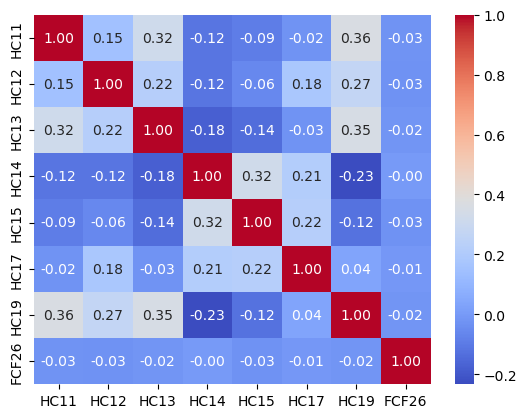

In [ ]:
sns.heatmap(df_hc_fcf26.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()